# **Introduction to the modeling and simulation of Cellular Wireless Communication Systems - Part 3**

In [2]:
import numpy as np
from analysis import coverage
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, HTML
from graphic import graphic_cdf, graphic_average_sum_capacity
from power_control import (objective_function_maxsum, power_control_dpc, 
    power_control_with_maxsum, power_control_with_maxprod, graf_sinr_and_power, analysis)


#  Exercise 1

In [ ]:
# Constants
f = 10  # frequency in Hz
T = 1   # total simulation time in seconds
fs = 10000  # sampling frequency in Hz (10 kHz)
time = np.arange(0, T, 1/fs)


s_los = np.sin(2 * np.pi * f * time)
s_reflected_pos1 = np.sin(2 * np.pi * f * (time - 0.010))
s_reflected_pos2 = np.sin(2 * np.pi * f * (time - 0.054))


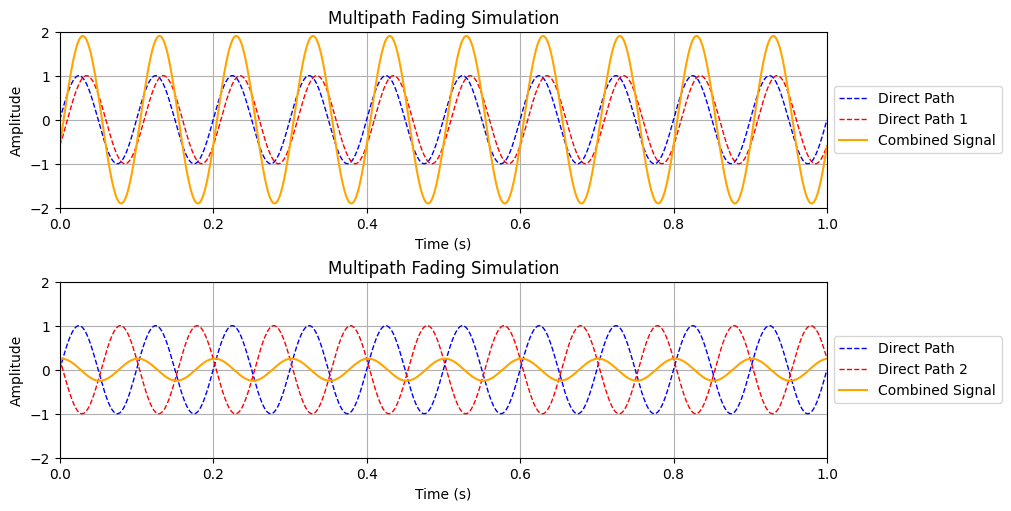

In [3]:
fig, graf = plt.subplots(2, figsize = (10, 5), constrained_layout=True)
graf[0].plot(time, s_los, linestyle="--", color="b", linewidth=1, label="Direct Path")
graf[0].plot(time, s_reflected_pos1, linestyle="--", color="r", linewidth=1,label="Direct Path 1")
graf[0].plot(time, s_los + s_reflected_pos1, color="orange", label="Combined Signal")
graf[0].set(title="Multipath Fading Simulation", xlabel = "Time (s)", ylabel = "Amplitude", xlim =(0, 1), ylim=(-2, 2))
graf[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
graf[0].grid(True)

graf[1].plot(time, s_los, linestyle="--", color="b", linewidth=1, label="Direct Path")
graf[1].plot(time, s_reflected_pos2, linestyle="--", color="r", linewidth=1, label="Direct Path 2")
graf[1].plot(time, s_los + s_reflected_pos2, color="orange", label="Combined Signal")
graf[1].set(title="Multipath Fading Simulation", xlabel = "Time (s)", ylabel = "Amplitude", xlim =(0, 1), ylim=(-2, 2))
graf[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
graf[1].grid(True)

plt.show()

**Comentário:** 

Para a UE na posição 1, apresentando um atraso de $10~ms$, a soma dos sinais gera uma interferência construtiva já que o atraso entre os sinais é pequeno e as duas senóides permanecem próximas em fase. Já para UE na posição 2, com um atraso de $54~ms$, a combinação dos sinais resulta em uma interferência destrutiva devido a diferença de fase entre as duas senóides.

# Exercise 2

In [ ]:
# Constants
f = 10        # frequency in Hz
fs = 10000    # sampling frequency in Hz (10 kHz)
time = np.arange(0, 1, 1/fs)

s_los = np.sin(2 * np.pi * f * time)
delays_s = np.arange(10, 55, 1) / 1000       

fig, graf = plt.subplots(figsize = (10, 5), constrained_layout=True)
graf.plot(time, s_los, linestyle="--", color="b", linewidth=1, label="Direct Path")
line1, = graf.plot(time, s_los, linestyle="--", color="r", linewidth=1,label="Direact Path 1")
line2, = graf.plot(time, s_los, color="orange", label="Combined Signal")
text = graf.text(0.8, 1.6, '', fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
graf.set(title="Multipath Fading Simulation", xlabel = "Time (s)", ylabel = "Amplitude", xlim =(0, 1), ylim=(-2, 2))
graf.legend(loc='center left', bbox_to_anchor=(1, 0.5))
graf.grid(True)

def update(frame):
    s_reflected = np.sin(2 * np.pi * f * (time - delays_s[frame]))
    line1.set_data(time, s_reflected)
    line2.set_data(time, s_los + s_reflected)
    text.set_text(f"{int(delays_s[frame]*1000)} ms")
    return line1, line2,  text

ani = animation.FuncAnimation(fig, update, frames=len(delays_s), interval=100, blit=True)
plt.close(fig)

display(HTML(ani.to_jshtml()))

**Comentário:**

Por meio desta animação, é possivel observar como o sinal combinado evolui quando o atraso do caminho refletido aumenta gradualmente de $10~ms$ para $54~ms$. Para pequenos valores de atrasos, a combinação de sinais apresenta uma interferência construtiva. Já para altos valores de atraso, ocorre um deslocamento de fase entre os sinais, resultando em uma interferência destrutiva e regiões de forte atenuação (cancelamento) na amplitude do sinal recebido.

# Exercise 3

In [5]:
N = int(1e6)
sigma_r = 1 
x1 = np.random.normal(0, sigma_r, N)
x2 = np.random.normal(0, sigma_r, N)

# Vetor Rayleigh
r = np.sqrt(x1**2 + x2**2)

print(f"mean(r): {np.mean(r):.4f} (Teórico: {sigma_r*np.sqrt(np.pi/2):.4f})")
print(f"mean(r²): {np.mean(r**2):.4f} (Teórico: {2*(sigma_r**2):.4f})")
print(f"var(r): {np.var(r):.4f} (Teórico: {((sigma_r**2)*(4 - np.pi)/2):.4f})")

mean(r): 1.2513 (Teórico: 1.2533)
mean(r²): 1.9939 (Teórico: 2.0000)
var(r): 0.4281 (Teórico: 0.4292)


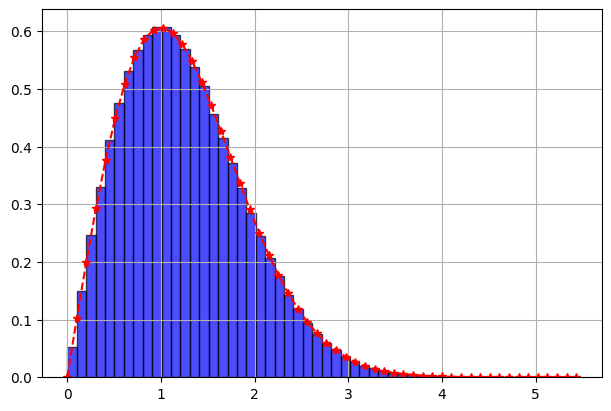

In [ ]:
r_vals = np.linspace(0, np.max(r), int(10*np.max(r)))
pdf = (r_vals/(sigma_r**2)) * np.exp(-r_vals**2 / 2*(sigma_r**2))

fig, graf = plt.subplots(figsize = (6, 4), constrained_layout=True)
count, bins, _ = graf.hist(r, bins=int(10*np.max(r)), density=True, alpha=0.7, edgecolor='black', color="b")
graf.plot(r_vals, pdf, color='red', marker='*', linestyle="--")
graf.grid(True)
plt.show()

**Comentário:**

Neste exercicio, foi possivel gerar valores para o Desvanencimento de Rayleigh apatir de variaveis aleatórias $x_1$ e $x_2$. O desvanencimento foi calculado como $r = \sqrt{x_1^2 + x_1^2}$ e com o valor de $r$, foi possivel calcular a média, o valor quadratico médio e a variância que ficaram próximos dos valores teóricos.


# Exercise 5

In [3]:
print("\nWith the Multipath Fading and Random Channel Allocation")
output = coverage(number_ue = 13, list_acess_point = [64], list_channel = range(1, 11), 
    shadow_effect = True, random_channel = True, channel_aggregation = False, power_control = False, 
    multipath_fading = True, verbose = True)


With the Multipath Fading and Random Channel Allocation

Para M = 64, K = 13, N = 1:
The 10th percentile of the SINR: 0.0603
The 50th percentile of the SINR: 4.8609
The 10th percentile of the Capacity Channel: 8.44 Mbps
The 50th percentile of the Capacity Channel: 255.11 Mbps
Average sum-capacity to 64 AP: 4643.96 Mbps
Spectrum efficiency to 64 AP: 46.44 bits/second/Hz/km²

Para M = 64, K = 13, N = 2:
The 10th percentile of the SINR: 0.2091
The 50th percentile of the SINR: 13.3015
The 10th percentile of the Capacity Channel: 13.70 Mbps
The 50th percentile of the Capacity Channel: 191.90 Mbps
Average sum-capacity to 64 AP: 2986.71 Mbps
Spectrum efficiency to 64 AP: 29.87 bits/second/Hz/km²

Para M = 64, K = 13, N = 3:
The 10th percentile of the SINR: 0.3713
The 50th percentile of the SINR: 22.7879
The 10th percentile of the Capacity Channel: 15.18 Mbps
The 50th percentile of the Capacity Channel: 152.41 Mbps
Average sum-capacity to 64 AP: 2253.21 Mbps
Spectrum efficiency to 64 AP: 22.5

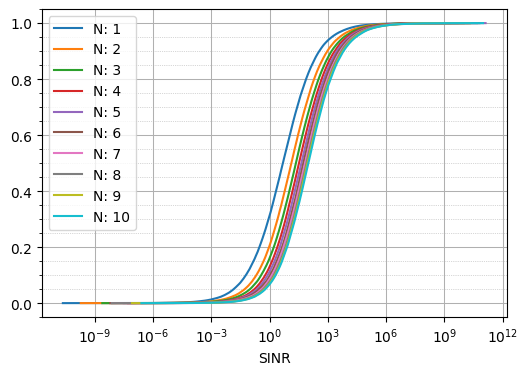

In [4]:
graphic_cdf(output, parameter="Channel", metric="SINR")

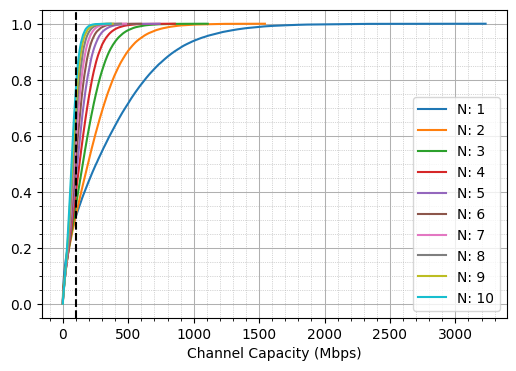

In [5]:
graphic_cdf(output, parameter="Channel", metric="Channel Capacity")

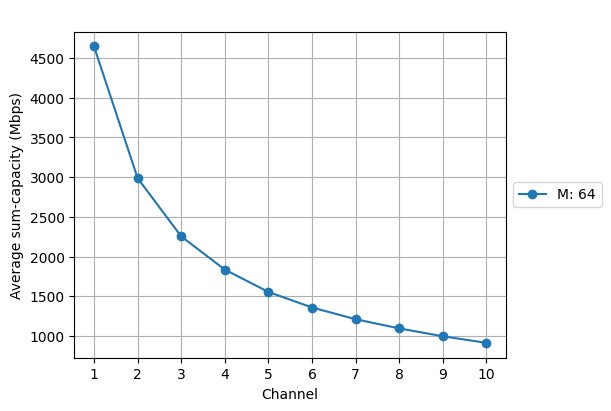

In [6]:
graphic_average_sum_capacity(output, parameter = "Channel")

**Comentário:**  

Utilizando a alocação aleatória para um cenário com $64$ APs e $13$ UEs, variando a quantidade de canais ($N$ de $1$ a $10$), observa-se que, para $N = 1$, os valores de SINR são mais baixos devido ao grande número de UEs compartilhando o mesmo canal. Entretanto, à medida que $N$ aumenta, as curvas de CDF do SINR deslocam-se para a direita, indicando que a alocação em múltiplos canais melhora o SINR, principalmente para os UEs em piores condições.

Ao avaliar a capacidade de canal, nota-se que o aumento de $N$ melhora o desempenho dos UEs com menores taxas (*fairness*), mas reduz o ganho máximo de capacidade individual, devido à divisão da largura de banda entre mais canais. Esse efeito é ainda mais evidente na *Average sum-capacity*, que apresenta relação inversa com o número de canais: a maior soma de capacidade é obtida em $N = 1$ (cenário de alta interferência e com largura de banda por usuário), enquanto este parâmetro decai com o aumento de $N$. 


# Exercise 6

In [7]:
print("\nWith the Multipath Fading and Per-AP Orthogonal Allocation (PAPOA)")
output_channel_PAPOA = coverage(number_ue = 13, list_acess_point = [64], list_channel = range(1, 11), shadow_effect = True, random_channel = False, channel_allocation = "PAPOA",
                  channel_aggregation = False,  power_control = False, multipath_fading = True, verbose = True)


With the Multipath Fading and Per-AP Orthogonal Allocation (PAPOA)

Para M = 64, K = 13, N = 1:
The 10th percentile of the SINR: 0.0614
The 50th percentile of the SINR: 4.8922
The 10th percentile of the Capacity Channel: 8.59 Mbps
The 50th percentile of the Capacity Channel: 255.88 Mbps
Average sum-capacity to 64 AP: 4661.93 Mbps
Spectrum efficiency to 64 AP: 46.62 bits/second/Hz/km²

Para M = 64, K = 13, N = 2:
The 10th percentile of the SINR: 0.4156
The 50th percentile of the SINR: 22.8960
The 10th percentile of the Capacity Channel: 25.07 Mbps
The 50th percentile of the Capacity Channel: 228.93 Mbps
Average sum-capacity to 64 AP: 3378.60 Mbps
Spectrum efficiency to 64 AP: 33.79 bits/second/Hz/km²

Para M = 64, K = 13, N = 3:
The 10th percentile of the SINR: 0.9715
The 50th percentile of the SINR: 47.7198
The 10th percentile of the Capacity Channel: 32.64 Mbps
The 50th percentile of the Capacity Channel: 186.88 Mbps
Average sum-capacity to 64 AP: 2633.38 Mbps
Spectrum efficiency to 

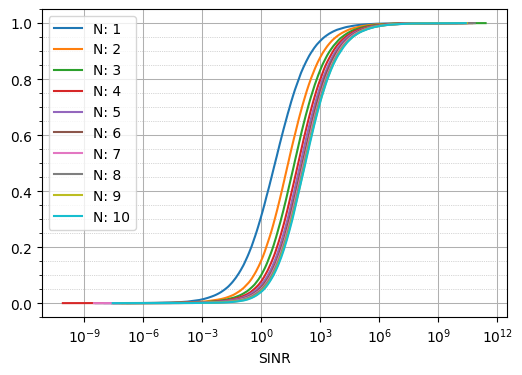

In [8]:
graphic_cdf(output_channel_PAPOA, parameter="Channel", metric="SINR")

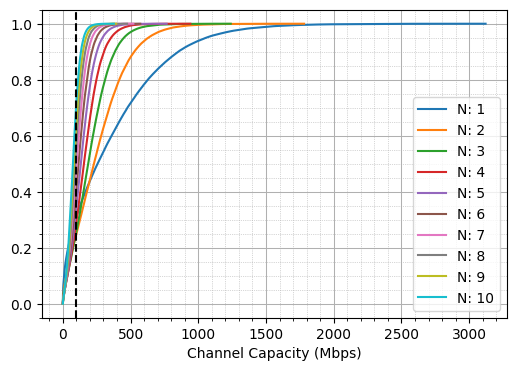

In [4]:
graphic_cdf(output_channel_PAPOA, parameter="Channel", metric="Channel Capacity")

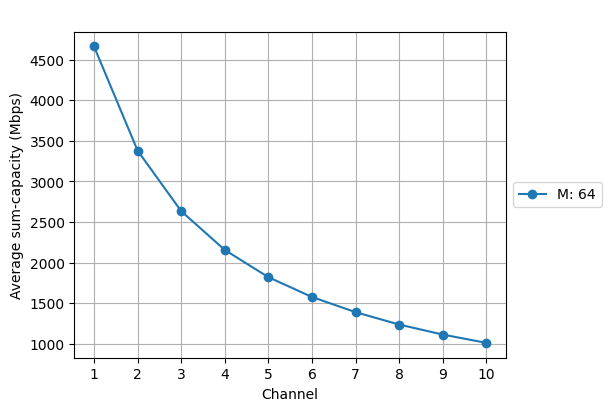

In [9]:
graphic_average_sum_capacity(output_channel_PAPOA, parameter = "Channel")

**Comentário:**  

Utilizando a alocação *Per-AP Orthogonal Allocation* (PAPOA) para um cenário com $64$ APs e $13$ UEs, variando a quantidade de canais ($N$ de 1 a 10), em que cada AP toma decisões de alocação localmente, afetando apenas os UEs a ele anexados e evitando a reutilização de canais dentro do mesmo AP. Nesse cenário, observa-se que as curvas de CDF do SINR deslocam-se para a direita, especialmente nos percentis mais baixos, indicando um melhor SINR para os UEs mais desfavorecidos.  

Ao avaliar a capacidade de canal, nota-se que o aumento de $N$ melhora o desempenho dos UEs com menores taxas (*fairness*), mas reduz o ganho máximo de capacidade individual, devido à divisão da largura de banda entre mais canais. Já a *Average sum-capacity* apresenta comportamento decrescente com o aumento de $N$, assim como na alocação aleatória; contudo, a alocação PAPOA tende a apresentar maior soma média de capacidade para $N > 1$, mostrando-se mais eficiente que a alocação aleatória em cenários com múltiplos canais.



# Exercise 8

In [10]:
print("\nWith the Multipath Fading and Interference-measurement based channel allocation (IMCA)")
output_channel_IMCA = coverage(number_ue = 13, list_acess_point = [64], list_channel = range(1, 11), 
    shadow_effect = True, random_channel = False, channel_allocation = "IMCA", channel_aggregation = False,  
    power_control = False, multipath_fading = True, verbose = True)


With the Multipath Fading and Interference-measurement based channel allocation (IMCA)

Para M = 64, K = 13, N = 1:
The 10th percentile of the SINR: 0.0631
The 50th percentile of the SINR: 4.8744
The 10th percentile of the Capacity Channel: 8.83 Mbps
The 50th percentile of the Capacity Channel: 255.44 Mbps
Average sum-capacity to 64 AP: 4656.02 Mbps
Spectrum efficiency to 64 AP: 46.56 bits/second/Hz/km²

Para M = 64, K = 13, N = 2:
The 10th percentile of the SINR: 0.4303
The 50th percentile of the SINR: 19.7574
The 10th percentile of the Capacity Channel: 25.82 Mbps
The 50th percentile of the Capacity Channel: 218.78 Mbps
Average sum-capacity to 64 AP: 3272.04 Mbps
Spectrum efficiency to 64 AP: 32.72 bits/second/Hz/km²

Para M = 64, K = 13, N = 3:
The 10th percentile of the SINR: 0.8979
The 50th percentile of the SINR: 35.5934
The 10th percentile of the Capacity Channel: 30.81 Mbps
The 50th percentile of the Capacity Channel: 173.12 Mbps
Average sum-capacity to 64 AP: 2489.09 Mbps
Spe

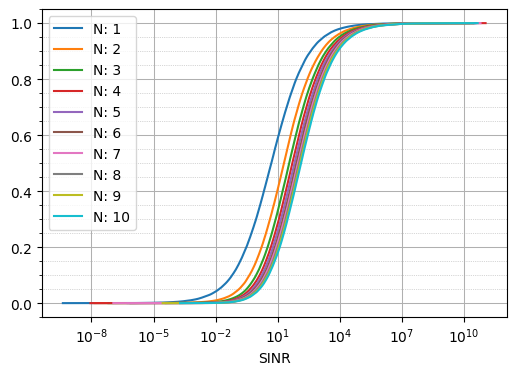

In [11]:
graphic_cdf(output_channel_IMCA, parameter="Channel", metric="SINR")

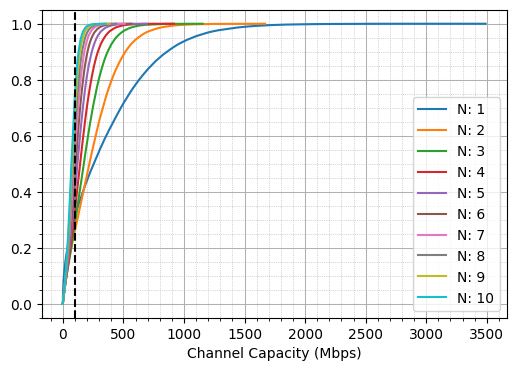

In [12]:
graphic_cdf(output_channel_IMCA, parameter="Channel", metric="Channel Capacity")

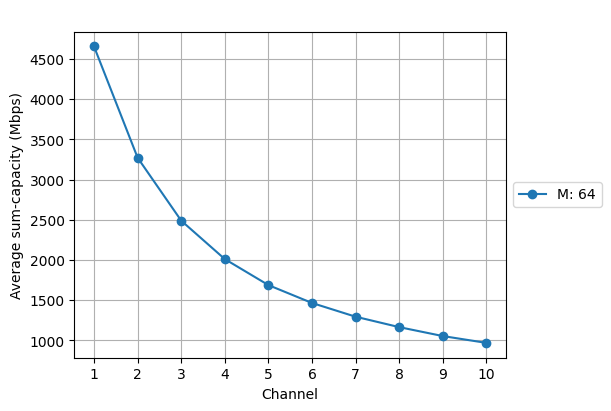

In [13]:
graphic_average_sum_capacity(output_channel_IMCA, parameter = "Channel")

**Comentário:**  

Utilizando a alocação *Interference-measurement based channel allocation* (IMCA) para um cenário com $64$ APs e $13$ UEs, variando a quantidade de canais ($N$ de 1 a 10), em que cada AP toma decisões de alocação baseada em informações sobre o status de alocação de canais em outros APs. Com isto, o AP tende a alocar os UEs para os canais que possivelmente tende a oferecer melhor SINR. Assim, as curvas de CDF do SINR deslocam-se ainda mais para a direita, evidenciando que a escolha baseada em medições de interferência reduz a alocação em canais com alto nível de ocupação e melhora o SINR médio. 

Ao avaliar a capacidade de canal, nota-se ganhos significativos no 10º percentil da capacidade, demonstrando maior equidade entre os UEs e melhor aproveitamento dos canais disponíveis. Com isso, temos que a *Average sum-capacity* com alocação IMCA supera o PAPOA em termos de soma da capacidade para a maioria dos valores de $N$, mantendo ganhos consideráveis de *fairness*. Essa melhora ocorre porque o IMCA utiliza informações do ambiente de interferência para otimizar a escolha dos canais, equilibrando eficiência espectral e justiça.

# Exercise 9 

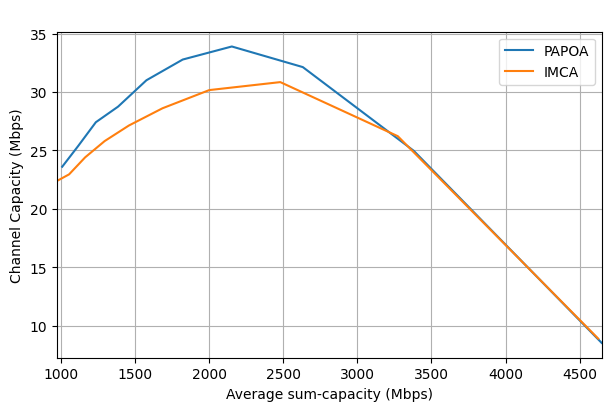

In [17]:
def graphic_exercise_9(output_PAPOA, output_IMCA):
    
    x_value_PAPOA, y_value_PAPOA = [], []
    for dict in output_PAPOA: 
        x_value_PAPOA.append(dict["Average sum-capacity"]) 
        y_value_PAPOA.append(np.percentile(dict["Channel Capacity"], 10))
        
    x_value_IMCA, y_value_IMCA = [], []
    for dict in output_IMCA: 
        x_value_IMCA.append(dict["Average sum-capacity"]) 
        y_value_IMCA.append(np.percentile(dict["Channel Capacity"], 10))
        
    fig, graf = plt.subplots(figsize = (6, 4), constrained_layout=True)
    graf.plot(x_value_PAPOA, y_value_PAPOA, label="PAPOA")
    graf.plot(x_value_IMCA, y_value_IMCA, label="IMCA")
    
    graf.set(xlim =(min(x_value_PAPOA+x_value_IMCA), max(x_value_PAPOA+x_value_IMCA)))
    graf.set(title=" ", ylabel = "Channel Capacity (Mbps)", xlabel="Average sum-capacity (Mbps)")
    graf.grid(True)
    graf.legend(loc='upper right')
    
    plt.show()
    
graphic_exercise_9(output_channel_PAPOA, output_channel_IMCA)
    

**Comentário:**

Ao plotar o par de pontos {x; y} = {*Average sum-capacity*; 10º percentil da capacidade por UE} para as alocações PAPOA e IMCA, observamos um *trade-off* claro entre eficiência espectral e *fairness*. Para valores menores de $N$, temos maior *Average sum-capacity*, mas o 10º percentil da capacidade é reduzido, indicando que alguns UEs ficam com desempenho muito baixo. À medida que $N$ aumenta, a curva se desloca para cima (melhorando o 10º percentil), porém à custa de uma queda na soma da capacidade do sistema. 

Comparando os métodos de alocação de canais, observa-se que PAPOA e IMCA apresentam comportamento semelhante para valores pequenos de $N$. Contudo, à medida que $N$ aumenta, o PAPOA tende a apresentar um 10º percentil superior, evidenciando melhor desempenho para os UEs em piores condições.


# Exercise 10

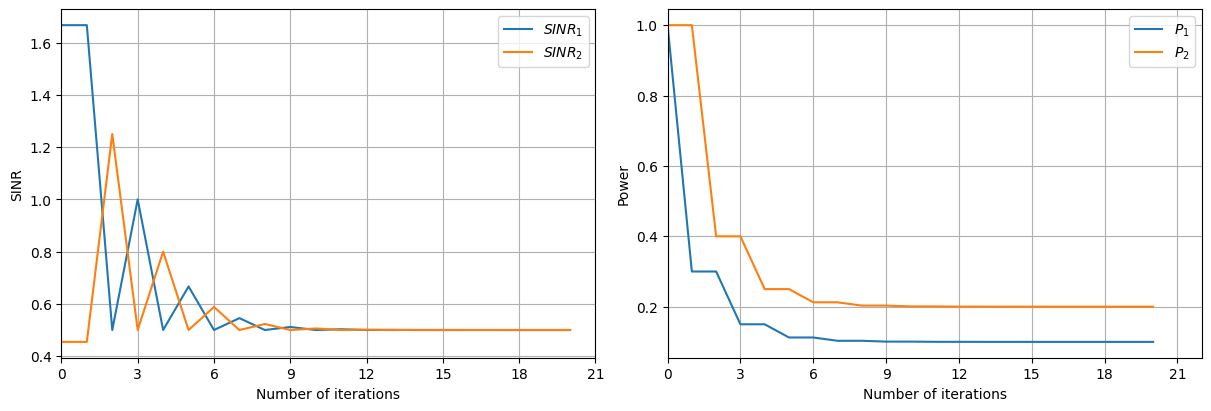

In [ ]:
sinr, power = power_control_dpc(
    scenario_type = "default", target_sinr=0.5, pmax=1, pmin=0, number_of_iterations=20)
graf_sinr_and_power(number_ue = 2, value_sinr=sinr, value_power=power)

In [5]:
print("=========== No Power Control ===========")
analysis(scenario_type="default", power=power[0])

print("\n=========== Distributed Power Control (DPC) ===========")
analysis(scenario_type="default", power=power[-1])

=========== No Power Control ===========
Power for UE 1: 1.0000 W
SINR for UE 1:  1.67
Channel Capacity for UE 1: 141.50 Mbps

Power for UE 2: 1.0000 W
SINR for UE 2:  0.45
Channel Capacity for UE 2: 54.06 Mbps

Sum Capacity: 195.56 Mbps
Energy Efficiency: 97.78 Mbits/J

=========== Distributed Power Control (DPC) ===========
Power for UE 1: 0.1000 W
SINR for UE 1:  0.50
Channel Capacity for UE 1: 58.50 Mbps

Power for UE 2: 0.2000 W
SINR for UE 2:  0.50
Channel Capacity for UE 2: 58.50 Mbps

Sum Capacity: 116.99 Mbps
Energy Efficiency: 389.97 Mbits/J


Neste exercício, foi implementado o algoritmo *Distributed Power Control* (DPC) com alvo de SINR ($\gamma = 0.5$). O sistema apresentou convergência rápida, em aproximadamente $10$ iterações, ajustando as potências dos UEs até atingir o valor de SINR definido. A aplicação dessa técnica resultou em melhoria da eficiência energética, mas a soma da capacidade foi limitada, refletindo o compromisso entre atingir o SINR alvo e manter a eficiência espectral.

# Exercise 11

### No power control

In [8]:
print("=========== No power control - Noise-limited scenario ===========")
analysis(scenario_type="Noise-limited", power=[1]*4)

print("\n=========== No power control - Interference-limited scenario ===========")
analysis(scenario_type="Interference-limited", power=[1]*4)

=========== No power control - Noise-limited scenario ===========
Power for UE 1: 1.0000 W
SINR for UE 1:  4.57
Channel Capacity for UE 1: 247.84 Mbps

Power for UE 2: 1.0000 W
SINR for UE 2:  0.01
Channel Capacity for UE 2: 1.11 Mbps

Power for UE 3: 1.0000 W
SINR for UE 3:  0.80
Channel Capacity for UE 3: 85.14 Mbps

Power for UE 4: 1.0000 W
SINR for UE 4:  0.01
Channel Capacity for UE 4: 1.32 Mbps

Sum Capacity: 335.40 Mbps
Energy Efficiency: 83.85 Mbits/J

=========== No power control - Interference-limited scenario ===========
Power for UE 1: 1.0000 W
SINR for UE 1:  92.69
Channel Capacity for UE 1: 654.98 Mbps

Power for UE 2: 1.0000 W
SINR for UE 2:  0.01
Channel Capacity for UE 2: 1.34 Mbps

Power for UE 3: 1.0000 W
SINR for UE 3:  89.21
Channel Capacity for UE 3: 649.52 Mbps

Power for UE 4: 1.0000 W
SINR for UE 4:  7.69
Channel Capacity for UE 4: 311.86 Mbps

Sum Capacity: 1617.70 Mbps
Energy Efficiency: 404.42 Mbits/J


### Distributed Power Control (DPC)

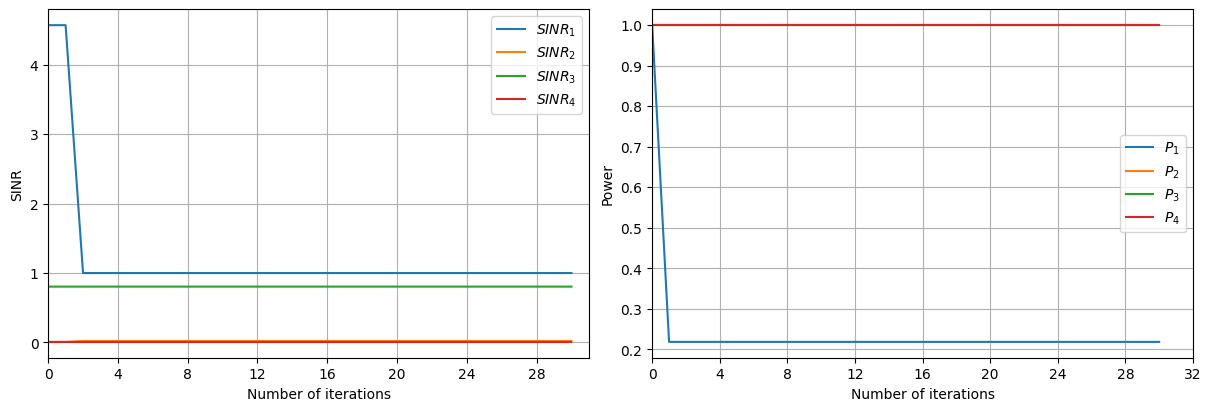

In [ ]:
sinr_nl, power_nl = power_control_dpc(
    scenario_type="Noise-limited", target_sinr=1, pmax=1, pmin=1e-3, number_of_iterations = 30)
graf_sinr_and_power(number_ue = 4, value_sinr=sinr_nl, value_power=power_nl)

In [10]:
print("=========== Distributed Power Control - Noise-limited scenario ===========")
analysis(scenario_type="Noise-limited", power=power_nl[-1])

=========== Distributed Power Control - Noise-limited scenario ===========
Power for UE 1: 0.2187 W
SINR for UE 1:  1.00
Channel Capacity for UE 1: 100.00 Mbps

Power for UE 2: 1.0000 W
SINR for UE 2:  0.02
Channel Capacity for UE 2: 3.11 Mbps

Power for UE 3: 1.0000 W
SINR for UE 3:  0.80
Channel Capacity for UE 3: 85.14 Mbps

Power for UE 4: 1.0000 W
SINR for UE 4:  0.01
Channel Capacity for UE 4: 1.32 Mbps

Sum Capacity: 189.56 Mbps
Energy Efficiency: 58.89 Mbits/J


**Comentário:**

Analisando o cenário *noise-limited*, observa-se que, sem controle de potência, as UE2 e UE4 apresentam valores muito baixos de SINR e, consequentemente, baixíssimas taxas de transmissão, enquanto a UE1 atinge aproximadamente 250 Mbps, demonstrando uma forte desigualdade no atendimento entre os usuários.

Com a aplicação do algoritmo *Distributed Power Control* (DPC), não houve mudanças significativas nos valores de SINR para UE2, UE3 e UE4, mas nota-se que a UE1 teve uma redução considerável na potência de transmissão, resultando em uma queda expressiva de capacidade (de aproximadamente 250 Mbps para 100 Mbps). Esse ajuste ilustra a característica principal do DPC: buscar a equalização dos valores de SINR entre os usuários, ao invés de privilegiar aqueles com melhores condições de canal.

Assim, o DPC tende a aplicar justiça entre todas as UEs, nivelando o desempenho e garantindo que todos atinjam um SINR próximo ao alvo definido, mesmo que isso implique em sacrificar a capacidade máxima que poderia ser alcançada por UEs em boas condições de canal. 

| UE                | Power (W) - No Power Control | SINR - No Power Control | Capacity (Mbps) - No Power Control | Power (W) - DPC | SINR - DPC | Capacity (Mbps) - DPC |
|-------------------|------------------------------|-------------------------|------------------------------------|-----------------|------------|-----------------------|
| UE1               | 1.0000                       | 4.57                    | 247.84                             | 0.2187          | 1.00       | 100.00                |
| UE2               | 1.0000                       | 0.01                    | 1.11                               | 1.0000          | 0.02       | 3.11                  |
| UE3               | 1.0000                       | 0.80                    | 85.14                              | 1.0000          | 0.80       | 85.14                 |
| UE4               | 1.0000                       | 0.01                    | 1.32                               | 1.0000          | 0.01       | 1.32                  |
| **Sum Capacity**      | -                            | -                       | **335.40 Mbps**                    | -               | -          | **189.56 Mbps**       |
| **Energy Efficiency** | -                            | -                       | **83.85 Mbps/J**                   | -               | -          | **58.89 Mbps/J**      |


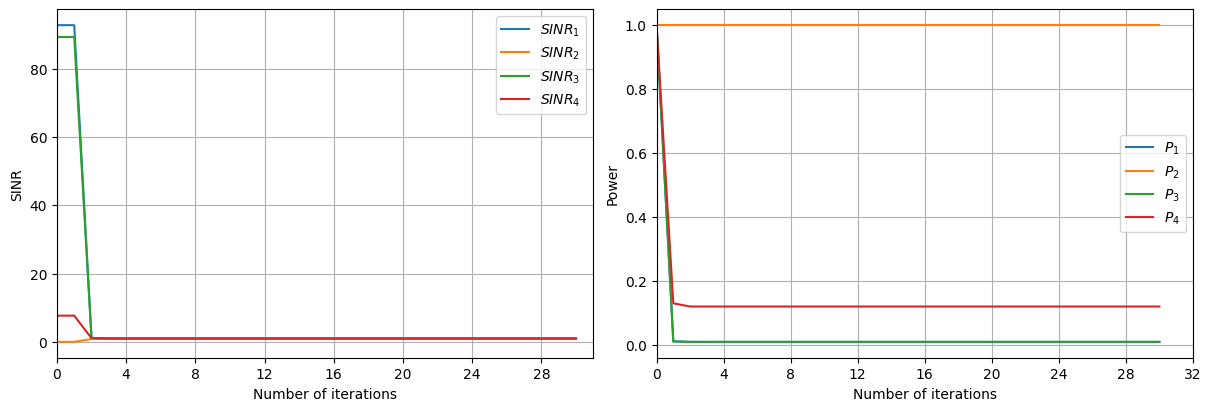

In [ ]:
sinr_il, power_il = power_control_dpc(
    scenario_type="Interference-limited", target_sinr=1, pmax=1, pmin=1e-3, number_of_iterations = 30)
graf_sinr_and_power(number_ue = 4, value_sinr=sinr_il, value_power=power_il)

In [12]:
print("=========== Distributed Power Control - Interference-limited scenario ===========")
analysis(scenario_type="Interference-limited", power=power_il[-1])

=========== Distributed Power Control - Interference-limited scenario ===========
Power for UE 1: 0.0095 W
SINR for UE 1:  1.00
Channel Capacity for UE 1: 100.00 Mbps

Power for UE 2: 1.0000 W
SINR for UE 2:  0.96
Channel Capacity for UE 2: 97.29 Mbps

Power for UE 3: 0.0095 W
SINR for UE 3:  1.00
Channel Capacity for UE 3: 100.00 Mbps

Power for UE 4: 0.1201 W
SINR for UE 4:  1.00
Channel Capacity for UE 4: 100.00 Mbps

Sum Capacity: 397.29 Mbps
Energy Efficiency: 348.80 Mbits/J


**Comentário:**

No cenário *interference-limited*, sem controle de potência, observa-se uma grande disparidade entre as UEs: enquanto as UE1 e UE3 atingem capacidades elevadíssimas (próximo de 650 Mbps), a UE2 têm desempenho extremamente baixo (em torno de 1 Mbps), evidenciando a concentração de recursos nos usuários com melhores condições de canal.

Com a aplicação do DPC, ocorre uma drástica redistribuição das potências transmitidas: as UEs com melhores canais (UE1, UE2 e UE3) reduzem suas potências para níveis mínimos, enquanto UE2  têm sua potência ajustadas no valor máximo para atingir o alvo de SINR. Esse balanceamento leva a uma equalização dos valores de SINR, que passam a ficar próximos de 1 para todos os usuários. Como consequência, a soma da capacidade do sistema cai de 1617.70 Mbps para 397.29 Mbps, refletindo a perda de eficiência espectral em troca de maior justiça entre os usuários. 


| UE  | Power (W) - No Power Control | SINR - No Power Control | Capacity (Mbps) - No Power Control | Power (W) - DPC | SINR - DPC | Capacity (Mbps) - DPC |
|-----|------------------------------|-------------------------|------------------------------------|-----------------|------------|-----------------------|
| UE1 | 1.0000                       | 92.69                   | 654.98                             | 0.0095          | 1.00       | 100.00                |
| UE2 | 1.0000                       | 0.01                    | 1.34                               | 1.0000          | 0.96       | 97.29                 |
| UE3 | 1.0000                       | 89.21                   | 649.52                             | 0.0095          | 1.00       | 100.00                |
| UE4 | 1.0000                       | 7.69                    | 311.86                             | 0.1201          | 1.00       | 100.00                |
| **Sum Capacity** | -               | -                       | **1617.70 Mbits**                  | -               | -          | **397.29 Mbits**      |
| **Energy Efficiency** | -         | -                       | **404.42 Mbits/J**                 | -               | -          | **348.80 Mbits/J**    |


# Exercise 12

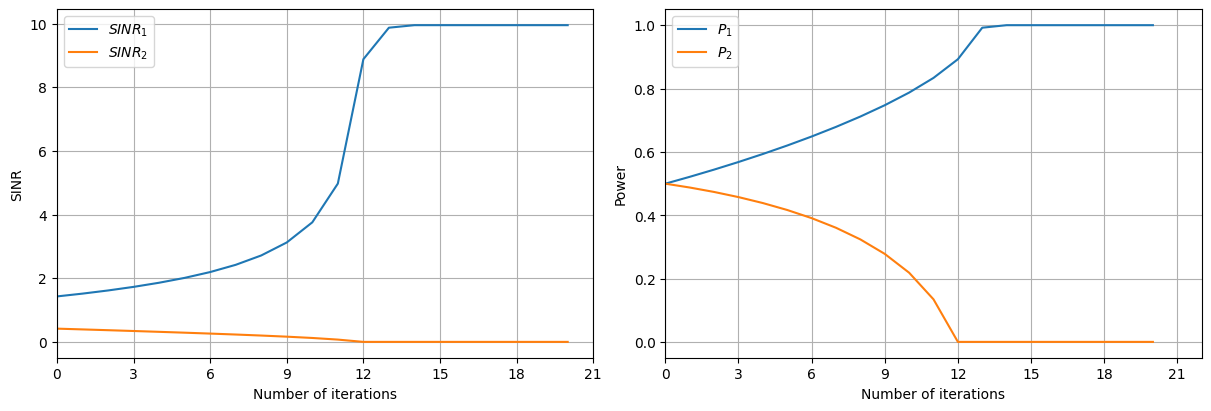

In [ ]:
sinr, power = power_control_with_maxsum(
    scenario_type = "default", pmax=1, pmin=1e-3, number_of_iterations=20, mu=1e-2, initial_power=0.5)
graf_sinr_and_power(number_ue = 2, value_sinr=sinr, value_power=power)

In [16]:
print("\n=========== Maxsum Power Control ===========")
analysis(scenario_type="default", power=power[-1])


=========== Maxsum Power Control ===========
Power for UE 1: 1.0000 W
SINR for UE 1:  9.95
Channel Capacity for UE 1: 345.29 Mbps

Power for UE 2: 0.0010 W
SINR for UE 2:  0.00
Channel Capacity for UE 2: 0.07 Mbps

Sum Capacity: 345.35 Mbps
Energy Efficiency: 345.01 Mbits/J


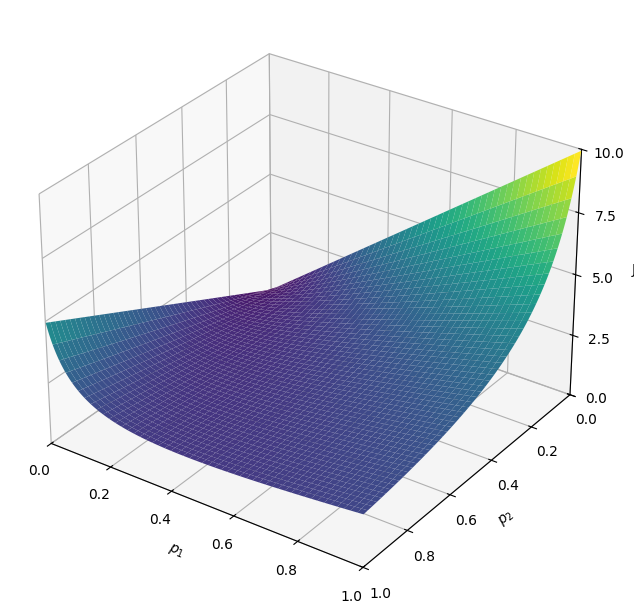

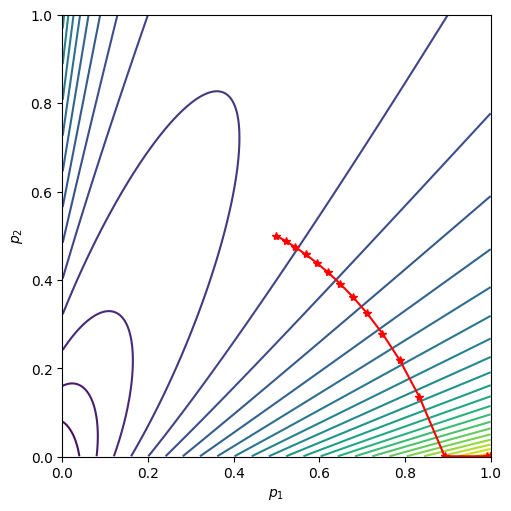

In [17]:
p_vals = np.linspace(0.001, 1, 1000)
power1, power2 = np.meshgrid(p_vals, p_vals)
Z = np.array([[objective_function_maxsum(scenario_type="default", power=[p1, p2]) for p1, p2 in zip(row1, row2)] for row1, row2 in zip(power1, power2)])

fig = plt.figure(figsize=(6,6), constrained_layout=True)
graf = fig.add_subplot(111, projection='3d')
graf.plot_surface(power1, power2, Z, cmap='viridis')
graf.set(xlabel=r"$p_1$", ylabel=r"$p_2$", zlabel="J")
graf.set(xlim=(1, 0), ylim=(0, 1), zlim=(0, 10))
graf.set(xticks=np.linspace(1,0,6), yticks=np.linspace(0,1,6), zticks=np.linspace(0,10,5))
graf.view_init(elev=30, azim=125)

plt.show()

fig, graf = plt.subplots(figsize=(5, 5), constrained_layout=True)
graf.contour(power1, power2, Z, levels=30, cmap='viridis')
graf.plot(power[:, 0], power[:, 1], 'r-*')
graf.set(xlim=(0, 1), ylim=(0, 1), xlabel=r"$p_1$", ylabel=r"$p_2$", title="")
plt.show()

**Comentário:**

Neste cenário, utilizando o *Maxsum Power Control*, a potência foi ajustada para maximizar a soma da capacidade, mesmo que isso ocorra à custa de usuários com piores condições de canal. Observa-se que a UE1 concentra praticamente toda a potência (1 W), atingindo uma capacidade de aproximadamente 345 Mbps, enquanto a UE2 recebe potência quase nula e, consequentemente, capacidade desprezível (0.07 Mbps). Esse ajuste extremo eleva a Sum Capacity para 345.35 Mbps, valor significativamente superior aos obtidos nos cenários sem controle (195.56 Mbps) e com DPC (116.99 Mbps).

| UE  | Power (W) - No Power Control | Capacity (Mbps) - No Power Control | Power (W) - DPC | Capacity (Mbps) - DPC | Power (W) - Maxsum | Capacity (Mbps) - Maxsum |
|-----|------------------------------|------------------------------------|-----------------|-----------------------|--------------------|-------------------------|
| UE1 | 1.0000                       | 141.50                             | 0.1000          | 58.50                 | 1.0000             | 345.29                  |
| UE2 | 1.0000                       | 54.06                              | 0.2000          | 58.50                 | 0.0010             | 0.07                    |
| **Sum Capacity**       | -        | **195.56 Mbps**                     | -               | **116.99 Mbps**       | -                  | **345.35 Mbps**         |
| **Energy Efficiency**  | -        | **97.78 Mbits/J**                   | -               | **389.97 Mbits/J**    | -                  | **345.01 Mbits/J**      |

No entanto, essa maximização ocorre em detrimento da justiça entre os usuários (*fairness*). Diferentemente do DPC, que busca equalizar os valores de SINR e distribuir melhor os recursos entre as UEs (mesmo com menor soma de capacidade), o *Maxsum* prioriza o usuário com melhor canal, deixando outros praticamente sem serviço.

# Exercise 13

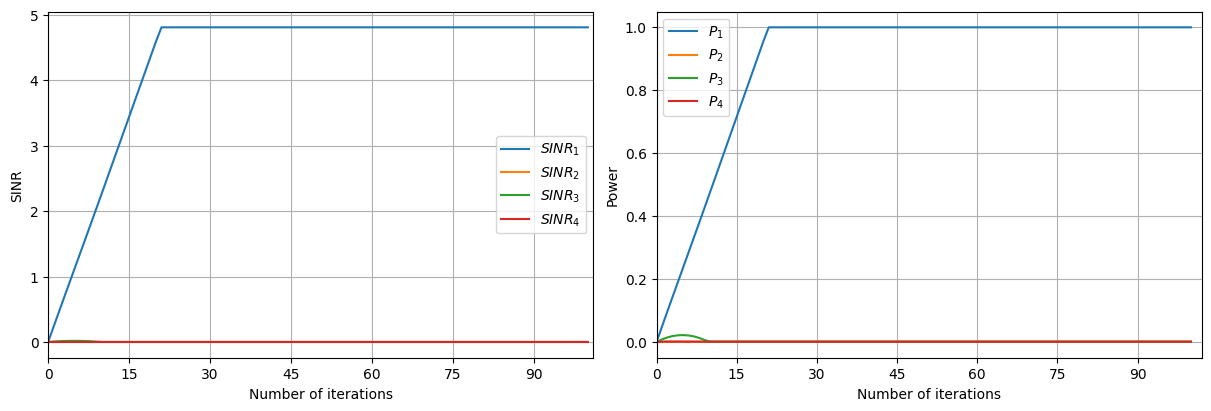

In [ ]:
sinr_nl, power_nl = power_control_with_maxsum(
    scenario_type="Noise-limited", pmax=1, pmin=1e-3, number_of_iterations = 100, mu=1e-2, initial_power=0)
graf_sinr_and_power(number_ue = 4, value_sinr=sinr_nl, value_power=power_nl)

In [19]:
print("\n=========== Maxsum Power Control - Noise-limited scenario ===========")
analysis(scenario_type="Noise-limited", power=power_nl[-1])


=========== Maxsum Power Control - Noise-limited scenario ===========
Power for UE 1: 1.0000 W
SINR for UE 1:  4.81
Channel Capacity for UE 1: 253.84 Mbps

Power for UE 2: 0.0010 W
SINR for UE 2:  0.00
Channel Capacity for UE 2: 0.00 Mbps

Power for UE 3: 0.0010 W
SINR for UE 3:  0.00
Channel Capacity for UE 3: 0.12 Mbps

Power for UE 4: 0.0010 W
SINR for UE 4:  0.00
Channel Capacity for UE 4: 0.00 Mbps

Sum Capacity: 253.96 Mbps
Energy Efficiency: 253.20 Mbits/J


**Comentário**

No cenário *noise-limited*, utilizando o *Maxsum Power Control*, a potência foi alocada quase que integralmente para a UE1, que atingiu aproximadamente 254 Mbps, enquanto as demais UEs receberam potências mínimas e apresentaram capacidades praticamente nulas. A Sum Capacity resultante (253.96 Mbps) foi superior àquela que seria obtida com uma distribuição mais justa de recursos, mas a falta de equidade entre os usuários reforça que o Maxsum sacrifica *fairness* em prol de maior eficiência espectral.

| UE  | Power (W) - No Power Control | Capacity (Mbps) - No Power Control | Power (W) - DPC | Capacity (Mbps) - DPC | Power (W) - Maxsum | Capacity (Mbps) - Maxsum |
|-----|------------------------------|------------------------------------|-----------------|-----------------------|--------------------|-------------------------|
| UE1 | 1.0000                       | 247.84                             | 0.2187          | 100.00                | 1.0000             | 253.84                  |
| UE2 | 1.0000                       | 1.11                               | 1.0000          | 3.11                  | 0.0010             | 0.00                    |
| UE3 | 1.0000                       | 85.14                              | 1.0000          | 85.14                 | 0.0010             | 0.12                    |
| UE4 | 1.0000                       | 1.32                               | 1.0000          | 1.32                  | 0.0010             | 0.00                    |
| **Sum Capacity**       | -        | **335.40 Mbps**                     | -               | **189.56 Mbps**       | -                  | **253.96 Mbps**         |
| **Energy Efficiency**  | -        | **83.85 Mbits/J**                   | -               | **58.89 Mbits/J**     | -                  | **253.20 Mbits/J**      |


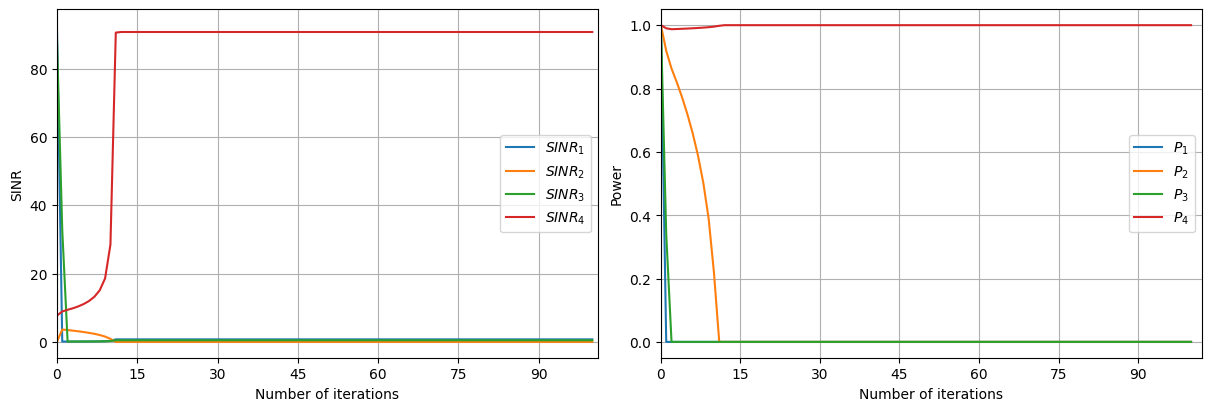

In [ ]:
sinr_il, power_il = power_control_with_maxsum(
    scenario_type="Interference-limited", pmax=1, pmin=1e-3, number_of_iterations = 100, mu=1e-4, initial_power=1)
graf_sinr_and_power(number_ue = 4, value_sinr=sinr_il, value_power=power_il)

In [21]:
print("\n=========== Maxsum Power Control - Interference-limited scenario ===========")
analysis(scenario_type="Interference-limited", power=power_il[-1])


=========== Maxsum Power Control - Interference-limited scenario ===========
Power for UE 1: 0.0010 W
SINR for UE 1:  0.74
Channel Capacity for UE 1: 80.18 Mbps

Power for UE 2: 0.0010 W
SINR for UE 2:  0.00
Channel Capacity for UE 2: 0.57 Mbps

Power for UE 3: 0.0010 W
SINR for UE 3:  0.48
Channel Capacity for UE 3: 56.26 Mbps

Power for UE 4: 1.0000 W
SINR for UE 4:  90.69
Channel Capacity for UE 4: 651.87 Mbps

Sum Capacity: 788.89 Mbps
Energy Efficiency: 786.53 Mbits/J


**Comentário:**

No cenário *interference-limited*, sem controle de potência, as UE1 e UE3 dominam o uso dos recursos com capacidades superiores a 649 Mbps, enquanto a UE2 apresenta desempenho extremamente baixo (1.34 Mbps). Já com o *Maxsum Power Control*, a alocação prioriza a UE4 (com melhor canal), que passa a ter 651.87 Mbps, enquanto UE1 e UE3 recebem potências mínimas e capacidades reduzidas, e a UE2 praticamente não é atendida. Esse comportamento resulta em uma soma de capacidade intermediária (788.89 Mbps) e a maior eficiência energética entre os métodos (786.53 Mbits/J), mas com forte perda de *fairness* entre ps usuários.


| UE  | Power (W) - No Power Control | Capacity (Mbps) - No Power Control | Power (W) - DPC | Capacity (Mbps) - DPC | Power (W) - Maxsum | Capacity (Mbps) - Maxsum |
|-----|------------------------------|------------------------------------|-----------------|-----------------------|--------------------|-------------------------|
| UE1 | 1.0000                       | 654.98                             | 0.0095          | 100.00                | 0.0010             | 80.18                   |
| UE2 | 1.0000                       | 1.34                               | 1.0000          | 97.29                 | 0.0010             | 0.57                    |
| UE3 | 1.0000                       | 649.52                             | 0.0095          | 100.00                | 0.0010             | 56.26                   |
| UE4 | 1.0000                       | 311.86                             | 0.1201          | 100.00                | 1.0000             | 651.87                  |
| **Sum Capacity**       | -        | **1617.70 Mbps**                    | -               | **397.29 Mbps**       | -                  | **788.89 Mbps**         |
| **Energy Efficiency**  | -        | **404.42 Mbits/J**                  | -               | **348.80 Mbits/J**    | -                  | **786.53 Mbits/J**      |


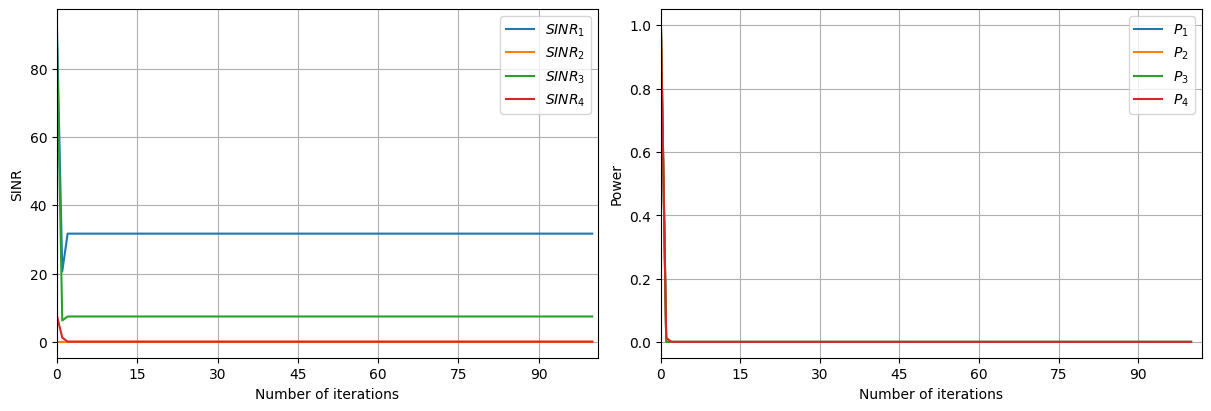

In [14]:
sinr_il, power_il = power_control_with_maxsum(
    scenario_type="Interference-limited", pmax=1, pmin=1e-3, number_of_iterations = 100, mu=1e-2, initial_power=1)
graf_sinr_and_power(number_ue = 4, value_sinr=sinr_il, value_power=power_il)

In [15]:
print("\n=========== Maxsum Power Control - Interference-limited scenario ===========")
analysis(scenario_type="Interference-limited", power=power_il[-1])


=========== Maxsum Power Control - Interference-limited scenario ===========
Power for UE 1: 0.0010 W
SINR for UE 1:  31.69
Channel Capacity for UE 1: 503.06 Mbps

Power for UE 2: 0.0010 W
SINR for UE 2:  0.01
Channel Capacity for UE 2: 1.31 Mbps

Power for UE 3: 0.0010 W
SINR for UE 3:  7.44
Channel Capacity for UE 3: 307.80 Mbps

Power for UE 4: 0.0010 W
SINR for UE 4:  0.09
Channel Capacity for UE 4: 12.52 Mbps

Sum Capacity: 824.70 Mbps
Energy Efficiency: 206174.35 Mbits/J


**Comentário:**  

Ainda no cenário *interference-limited*, alterei o parâmetro $\mu$ de $10^{-4}$ para $10^{-2}$. Com $\mu = 10^{-2}$, o ponto "ótimo" deslocou-se para uma alocação de potência mínima para todos os UEs ($0.001\,W$), resultando em uma Sum Capacity de 824.70 Mbps e um ganho expressivo em Eficiência Energética (206174.35 Mbits/J). Por outro lado, para $\mu = 10^{-4}$ observou-se uma alocação assimétrica de potência, com um dos UEs operando em potência máxima ($1\,W$), resultando em Sum Capacity de 788.89 Mbps e Eficiência Energética de 786.53 Mbits/J.  




# Exercise 14

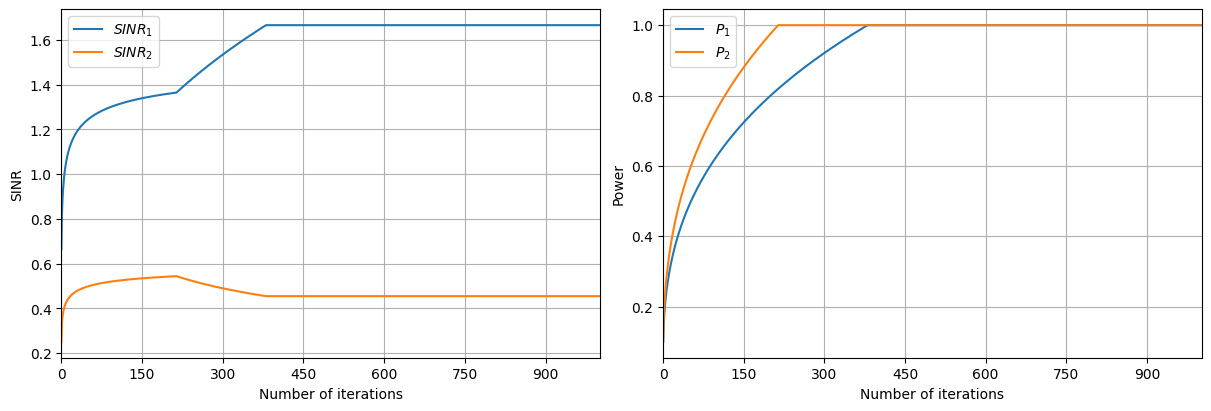

In [ ]:
sinr, power = power_control_with_maxprod(
    scenario_type = "default", pmax=1, pmin=1e-3, number_of_iterations=1000, mu=1e-2, initial_power=0.1)
graf_sinr_and_power(number_ue = 2, value_sinr=sinr, value_power=power)

In [25]:
print("\n=========== Maxprod Power Control ===========")
analysis(scenario_type="default", power=power[-1])


=========== Maxprod Power Control ===========
Power for UE 1: 1.0000 W
SINR for UE 1:  1.67
Channel Capacity for UE 1: 141.50 Mbps

Power for UE 2: 1.0000 W
SINR for UE 2:  0.45
Channel Capacity for UE 2: 54.06 Mbps

Sum Capacity: 195.56 Mbps
Energy Efficiency: 97.78 Mbits/J


**Comentário:**

Neste cenário, o *Maxprod Power Control*, o algoritmo buscou equilibrar *throughput* total e *fairness*. Houve redistribuição mais justa das potências entre os UEs, garantindo que todos tivessem capacidade mínima razoável, mas a soma da capacidade caiu em relação ao *Maxsum Power Control*. 

Observa-se que *No Power Control* e *Maxprod Power Control* apresentam o mesmo resultado numérico: a potência é igualmente distribuída entre as UEs, resultando em capacidades de 141.50 Mbps para a UE1 e 54.06 Mbps para a UE2. Essa estratégia mantém um certo equilíbrio entre os usuários, porém não explora plenamente o potencial de maximização do throughput do sistema.


| UE  | Power (W) - No Power Control | Capacity (Mbps) - No Power Control | Power (W) - Maxprod | Capacity (Mbps) - Maxprod | Power (W) - Maxsum | Capacity (Mbps) - Maxsum |
|-----|------------------------------|------------------------------------|---------------------|--------------------------|--------------------|-------------------------|
| UE1 | 1.0000                       | 141.50                             | 1.0000              | 141.50                   | 1.0000             | 345.29                  |
| UE2 | 1.0000                       | 54.06                              | 1.0000              | 54.06                    | 0.0010             | 0.07                    |
| **Sum Capacity**       | -        | **195.56 Mbps**                     | -                   | **195.56 Mbps**          | -                  | **345.35 Mbps**         |
| **Energy Efficiency**  | -        | **97.78 Mbits/J**                   | -                   | **97.78 Mbits/J**        | -                  | **345.01 Mbits/J**      |


# Exercise 15

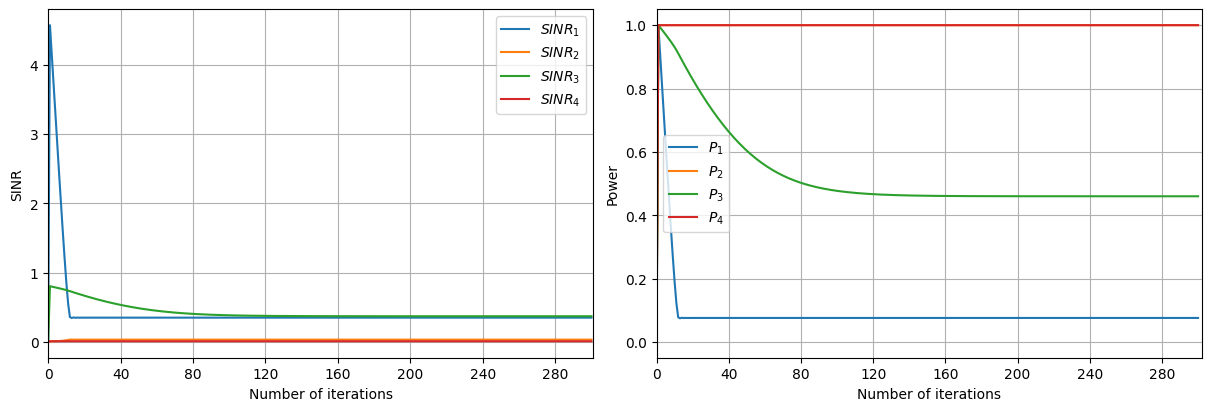

In [16]:
sinr_nl, power_nl = power_control_with_maxprod(
    scenario_type="Noise-limited", pmax=1, pmin=1e-3, number_of_iterations = 300, mu=1e-2, initial_power=1e-3)
graf_sinr_and_power(number_ue = 4, value_sinr=sinr_nl, value_power=power_nl)

In [31]:
print("\n=========== Maxprod Power Control - Noise-limited scenario ===========")
analysis(scenario_type="Noise-limited", power=power_nl[-1])


=========== Maxprod Power Control - Noise-limited scenario ===========
Power for UE 1: 0.0765 W
SINR for UE 1:  0.35
Channel Capacity for UE 1: 43.29 Mbps

Power for UE 2: 1.0000 W
SINR for UE 2:  0.03
Channel Capacity for UE 2: 4.63 Mbps

Power for UE 3: 0.4603 W
SINR for UE 3:  0.37
Channel Capacity for UE 3: 45.43 Mbps

Power for UE 4: 1.0000 W
SINR for UE 4:  0.01
Channel Capacity for UE 4: 1.32 Mbps

Sum Capacity: 94.67 Mbps
Energy Efficiency: 37.32 Mbits/J


**Comentário:**

No cenário *noise-limited*, observa-se que o *Maxprod Power Control* busca um compromisso entre fairness e eficiência, redistribuindo potências para tentar equilibrar capacidades, porém a soma da capacidade cai para 94.67 Mbps, com pior eficiência energética (37.32 Mbits/J).

| UE  | Power (W) - No Power Control | Capacity (Mbps) - No Power Control | Power (W) - Maxprod | Capacity (Mbps) - Maxprod | Power (W) - Maxsum | Capacity (Mbps) - Maxsum |
|-----|------------------------------|------------------------------------|---------------------|--------------------------|--------------------|-------------------------|
| UE1 | 1.0000                       | 247.84                             | 0.0765              | 43.29                    | 1.0000             | 253.84                  |
| UE2 | 1.0000                       | 1.11                               | 1.0000              | 4.63                     | 0.0010             | 0.00                    |
| UE3 | 1.0000                       | 85.14                              | 0.4603              | 45.43                    | 0.0010             | 0.12                    |
| UE4 | 1.0000                       | 1.32                               | 1.0000              | 1.32                     | 0.0010             | 0.00                    |
| **Sum Capacity**       | -        | **335.40 Mbps**                     | -                   | **94.67 Mbps**           | -                  | **253.96 Mbps**         |
| **Energy Efficiency**  | -        | **83.85 Mbits/J**                   | -                   | **37.32 Mbits/J**        | -                  | **253.20 Mbits/J**      |



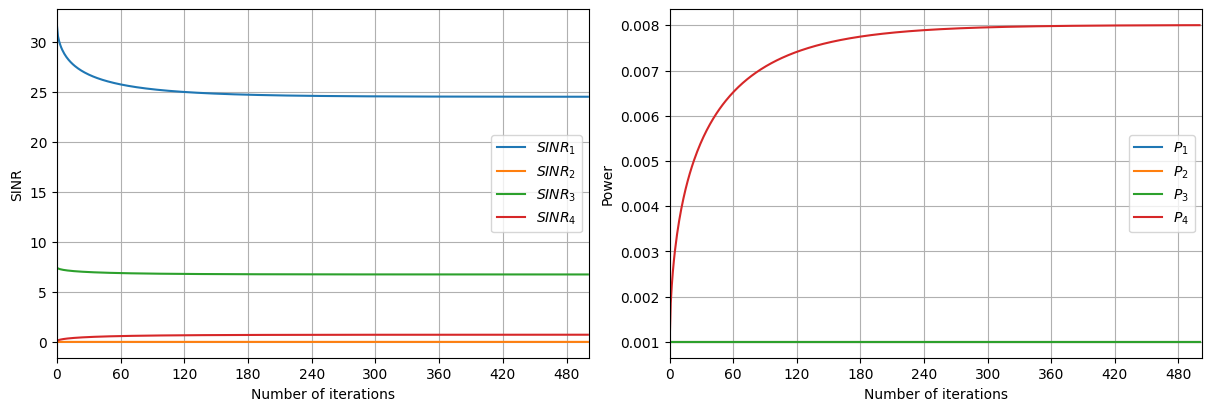

In [20]:
sinr_il, power_il = power_control_with_maxprod(
    scenario_type="Interference-limited", pmax=1, pmin=1e-3, number_of_iterations = 500, mu=1e-6, initial_power=1e-3)
graf_sinr_and_power(number_ue = 4, value_sinr=sinr_il, value_power=power_il)

In [33]:
print("\n=========== Maxprod Power Control - Interference-limited scenario ===========")
analysis(scenario_type="Interference-limited", power=power_il[-1])


=========== Maxprod Power Control - Interference-limited scenario ===========
Power for UE 1: 0.0010 W
SINR for UE 1:  24.53
Channel Capacity for UE 1: 467.40 Mbps

Power for UE 2: 0.0010 W
SINR for UE 2:  0.01
Channel Capacity for UE 2: 1.30 Mbps

Power for UE 3: 0.0010 W
SINR for UE 3:  6.75
Channel Capacity for UE 3: 295.48 Mbps

Power for UE 4: 0.0080 W
SINR for UE 4:  0.73
Channel Capacity for UE 4: 78.73 Mbps

Sum Capacity: 842.90 Mbps
Energy Efficiency: 76606.66 Mbits/J


**Comentário:**

No cenário *interference-limited*, o *Maxprod Power Control* apresenta um comportamento mais distribuído entre as UEs, alcançando 842.90 Mbps de soma de capacidade com uma eficiência energética extremamente alta (76606.66 Mbits/J), demonstrando que esse algoritmo busca equilibrar a utilização dos recursos, ainda que com uma soma de capacidade inferior ao cenário sem controle (1617.70 Mbps).

| UE  | Power (W) - No Power Control | Capacity (Mbps) - No Power Control | Power (W) - Maxprod | Capacity (Mbps) - Maxprod | Power (W) - Maxsum | Capacity (Mbps) - Maxsum |
|-----|------------------------------|------------------------------------|---------------------|--------------------------|--------------------|-------------------------|
| UE1 | 1.0000                       | 654.98                             | 0.0010              | 467.40                   | 0.0010             | 80.18                   |
| UE2 | 1.0000                       | 1.34                               | 0.0010              | 1.30                     | 0.0010             | 0.57                    |
| UE3 | 1.0000                       | 649.52                             | 0.0010              | 295.48                   | 0.0010             | 56.26                   |
| UE4 | 1.0000                       | 311.86                             | 0.0080              | 78.73                    | 1.0000             | 651.87                  |
| **Sum Capacity**       | -        | **1617.70 Mbps**                    | -                   | **842.90 Mbps**          | -                  | **788.89 Mbps**         |
| **Energy Efficiency**  | -        | **404.42 Mbits/J**                  | -                   | **76606.66 Mbits/J**     | -                  | **786.53 Mbits/J**      |


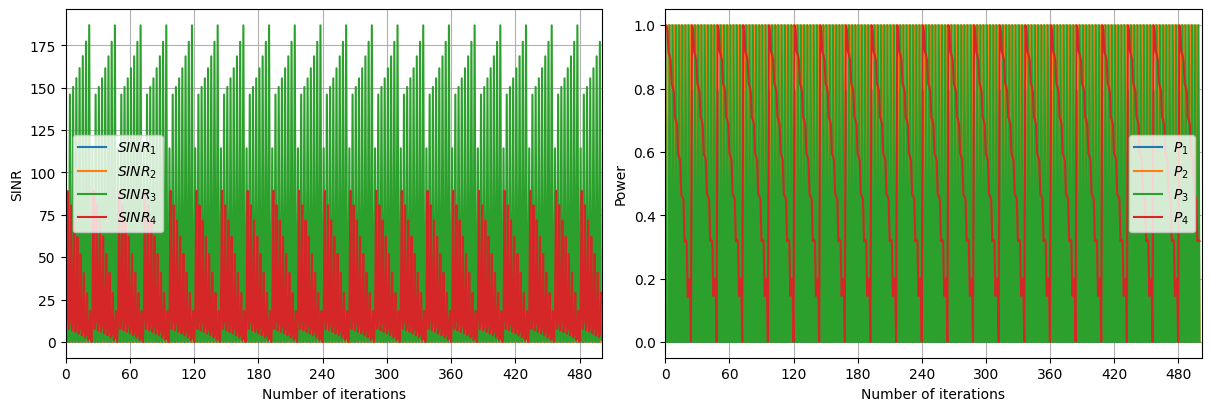

In [ ]:
sinr_il, power_il = power_control_with_maxprod(
    scenario_type="Interference-limited", pmax=1, pmin=1e-3, number_of_iterations = 500, mu=1e-2, initial_power=1e-3)
graf_sinr_and_power(number_ue = 4, value_sinr=sinr_il, value_power=power_il)

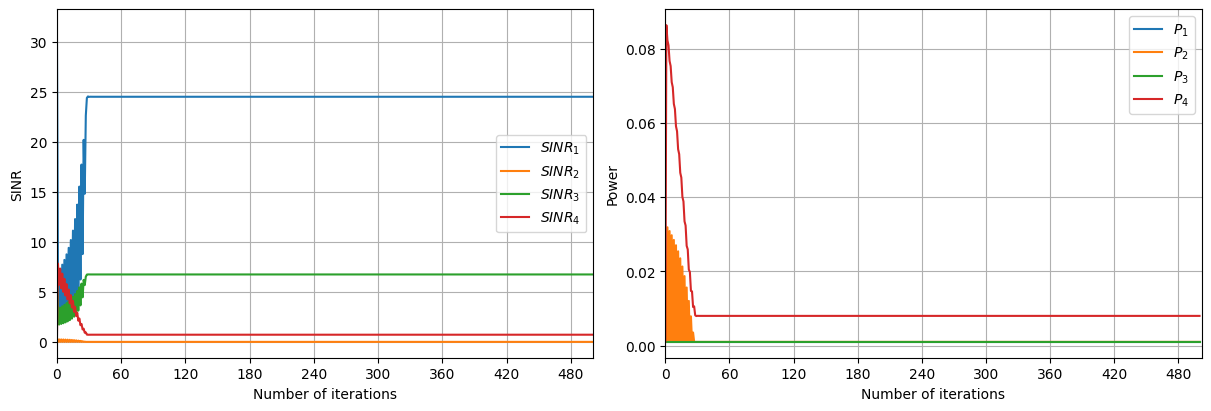

In [28]:
sinr_il, power_il = power_control_with_maxprod(
    scenario_type="Interference-limited", pmax=1, pmin=1e-3, number_of_iterations = 500, mu=1e-4, initial_power=1e-3)
graf_sinr_and_power(number_ue = 4, value_sinr=sinr_il, value_power=power_il)

**Comentário:**  

No cenário *interference-limited*, a variação do parâmetro $\mu$ no *Maxprod Power Control* exerce influência direta sobre a estratégia de alocação de potência e no comportamento dinâmico do sistema:

- Para $\mu = 10^{-6}$, observa-se um comportamento gradual e estável, no qual um dos UEs aumenta lentamente sua potência até um patamar intermediário (≈8 mW), enquanto os demais permanecem no valor mínimo.

- Com $\mu = 10^{-4}$, nas primeiras iterações é possível observar um efeito oscilatório, mas ao longo do processo essa oscilação é minimizada, retornando a uma solução estável, em que um dos UEs foi alocado com potência de, aproximadamente, 8mW, enquanto os demais permanecem próximos a potência mínimo. Resultado similar ao que foi foi obtido com $\mu = 10^{-6}$.

- Por fim, para $\mu = 10^{-2}$, é perceptível um efeito oscilatório durante as iterações, evidenciado pelas variações periódicas de SINR e potência. Isso sugere que, com valores elevados de $\mu$, o algoritmo realiza ajustes mais agressivos a cada iteração, causando flutuações antes da estabilização.
